In [1]:
## ── PHASE A: IMPORTS & CONFIG ──────────────────────────────

import numpy as np
import pandas as pd
import pickle
import random
import json
import warnings
import gc
from pathlib import Path
from collections import Counter
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler
import torchvision.transforms as transforms
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report, f1_score
)
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# ── Reproducibility ──
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── Device ──
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Device : {device}")
if torch.cuda.is_available():
    print(f"  GPU    : {torch.cuda.get_device_name(0)}")

✓ Device : cuda
  GPU    : NVIDIA GeForce RTX 3050 Laptop GPU


In [2]:
# ── Paths ──
BASE_DIR             = Path(".")
PROCESSED_DIR        = BASE_DIR / "processed_data"
PROCESSED_CADICA_DIR = PROCESSED_DIR / "CADICA"
PROCESSED_NHANES_DIR = PROCESSED_DIR / "NHANES"
RESULTS_DIR          = BASE_DIR / "results"
RESULTS_DIR.mkdir(exist_ok=True)

# ── Label maps ──
LABEL_MAPPING         = {"Normal": 0, "Mild": 1, "Severe": 2}
INVERSE_LABEL_MAPPING = {0: "Normal", 1: "Mild", 2: "Severe"}
NUM_CLASSES           = 3

# ── Hyper-parameters ──
BATCH_SIZE   = 32
NUM_WORKERS  = 0        # keep 0 for Windows safety
IMG_SIZE     = 224

print("✓ Config loaded")

✓ Config loaded


In [3]:
## ── PHASE B: DATASET CLASSES ───────────────────────────────

class CADICADataset(Dataset):
    """
    Memory-safe shard-based CADICA loader.
    Loads exactly ONE shard into RAM at a time.
    """
    def __init__(self, split_dir, augment=False):
        self.split_dir = split_dir
        self.augment   = augment
        self.shards    = sorted(split_dir.glob("*.npz"))
        self.index     = []
        self.labels_map = []

        for s_idx, shard in enumerate(self.shards):
            with np.load(shard) as d:
                for l_idx, lbl in enumerate(d["labels"]):
                    self.index.append((s_idx, l_idx))
                    self.labels_map.append(int(lbl))

        print(f"  CADICA {split_dir.name}: {len(self.index)} samples "
              f"from {len(self.shards)} shards")

        self._cache_idx  = None
        self._cache_imgs = None
        self._cache_lbls = None

        norm = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                    std =[0.229, 0.224, 0.225])

        self.tf_aug = transforms.Compose([
            transforms.ToPILImage(),
            transforms.RandomHorizontalFlip(0.5),
            transforms.RandomVerticalFlip(0.2),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2,
                                   saturation=0.1, hue=0.05),
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1),
                                    scale=(0.9, 1.1)),
            transforms.ToTensor(), norm
        ])
        self.tf_base = transforms.Compose([
            transforms.ToPILImage(),
            transforms.ToTensor(), norm
        ])

    def _load_shard(self, idx):
        if self._cache_idx != idx:
            d = np.load(self.shards[idx])
            self._cache_imgs = d["images"]
            self._cache_lbls = d["labels"]
            self._cache_idx  = idx

    def __len__(self):
        return len(self.index)

    def __getitem__(self, idx):
        s_idx, l_idx = self.index[idx]
        self._load_shard(s_idx)
        img   = self._cache_imgs[l_idx]
        label = self.labels_map[idx]
        img   = np.clip(img, 0, 1)
        img   = (img * 255).astype(np.uint8)
        img   = self.tf_aug(img) if self.augment else self.tf_base(img)
        return img, torch.tensor(label, dtype=torch.long)

In [4]:
## ── PHASE C: FOCAL LOSS ────────────────────────────────────

class FocalLoss(nn.Module):
    """
    Focal loss with class weights.
    gamma=2 focuses learning on hard/minority examples.
    """
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha   # class weight tensor
        self.gamma = gamma

    def forward(self, logits, targets):
        ce  = F.cross_entropy(logits, targets,
                              weight=self.alpha, reduction="none")
        pt  = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma * ce).mean()
        return loss

In [5]:
## ── PHASE D: CNN BASELINE (unchanged, for reference) ───────

class CNNBaseline(nn.Module):
    def __init__(self, num_classes=3, pretrained=True):
        super().__init__()
        weights = ResNet18_Weights.DEFAULT if pretrained else None
        self.backbone = resnet18(weights=weights)
        feat_dim = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()
        self.classifier = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Dropout(0.4),
            nn.Linear(feat_dim, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.backbone(x))

In [6]:
## ── PHASE E: FUSION MODEL ──────────────────────────────────

class ClinicalEncoder(nn.Module):
    """
    Maps raw NHANES feature vector → 3-class clinical logits.
    Acts as a population-level CAD risk prior.
    """
    def __init__(self, in_dim: int, hidden: int = 256, num_classes: int = 3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(hidden, hidden // 2),
            nn.BatchNorm1d(hidden // 2),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(hidden // 2, 64),
            nn.GELU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.net(x)


class FusionGate(nn.Module):
    """
    Learnable weighted combination of image logits and clinical logits.
    gate = σ(W · [img_logit ; clin_logit])   ∈ (0,1)
    output = gate * img_logit + (1-gate) * clin_logit
    """
    def __init__(self, num_classes: int = 3):
        super().__init__()
        self.gate = nn.Sequential(
            nn.Linear(num_classes * 2, 32),
            nn.GELU(),
            nn.Linear(32, num_classes),
            nn.Sigmoid()
        )

    def forward(self, img_logit, clin_logit):
        g = self.gate(torch.cat([img_logit, clin_logit], dim=1))
        return g * img_logit + (1.0 - g) * clin_logit


class FusionModel(nn.Module):
    """
    Full multimodal fusion model.

    Image branch  : ResNet18 → 3 image logits
    Clinical branch: MLP(raw NHANES features) → 3 clinical logits
    Fusion gate   : learned α ∈ (0,1)³ per sample
    """
    def __init__(self, clinical_dim: int, num_classes: int = 3,
                 pretrained: bool = True):
        super().__init__()

        # ── Image branch ──
        weights = ResNet18_Weights.DEFAULT if pretrained else None
        backbone = resnet18(weights=weights)
        feat_dim = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.vision_encoder = backbone

        self.image_head = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Dropout(0.4),
            nn.Linear(feat_dim, 256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

        # ── Clinical branch ──
        self.clinical_encoder = ClinicalEncoder(
            clinical_dim, hidden=256, num_classes=num_classes
        )

        # ── Fusion gate ──
        self.fusion_gate = FusionGate(num_classes)

    def forward(self, images, clinical):
        # Image logits
        img_feat  = self.vision_encoder(images)
        img_logit = self.image_head(img_feat)

        # Clinical logits
        clin_logit = self.clinical_encoder(clinical)

        # Gated fusion
        out = self.fusion_gate(img_logit, clin_logit)
        return out, img_logit, clin_logit   # return aux outputs for multi-task loss

In [7]:
## ── PHASE F: LOAD DATA ─────────────────────────────────────

print("\n" + "=" * 60)
print("LOADING DATASETS")
print("=" * 60)

train_cadica = CADICADataset(PROCESSED_CADICA_DIR / "train", augment=True)
val_cadica   = CADICADataset(PROCESSED_CADICA_DIR / "val",   augment=False)
test_cadica  = CADICADataset(PROCESSED_CADICA_DIR / "test",  augment=False)

# ── Load NHANES ──
nhanes_csv = PROCESSED_NHANES_DIR / "NHANES_clean.csv"
nhanes_xgb = PROCESSED_NHANES_DIR / "nhanes_xgb.pkl"
scaler_pkl = PROCESSED_NHANES_DIR / "nhanes_scaler.pkl"

assert nhanes_csv.exists(), "Run nhanes_preprocessing.py first!"

nhanes_df  = pd.read_csv(nhanes_csv)
feat_cols  = [c for c in nhanes_df.columns if c not in ["SEQN", "risk_label"]]
X_nhanes   = nhanes_df[feat_cols].values.astype(np.float32)

CLINICAL_DIM = X_nhanes.shape[1]
print(f"\n✓ NHANES loaded: {len(nhanes_df)} rows, {CLINICAL_DIM} features")


LOADING DATASETS
  CADICA train: 7165 samples from 28 shards
  CADICA val: 1813 samples from 8 shards
  CADICA test: 2438 samples from 10 shards

✓ NHANES loaded: 11933 rows, 22 features


In [8]:
## ── PHASE G: BUILD CLINICAL TENSORS ────────────────────────

print("\n" + "=" * 60)
print("BUILDING CLASS-CONDITIONAL CLINICAL TENSORS")
print("=" * 60)

# XGB risk predictions on all NHANES rows
with open(nhanes_xgb, "rb") as f:
    xgb_model = pickle.load(f)

nhanes_preds = xgb_model.predict(X_nhanes)          # shape (N_nhanes,)

# Pool NHANES feature vectors by risk class
nhanes_pool = {cls: [] for cls in range(NUM_CLASSES)}
for feat, pred in zip(X_nhanes, nhanes_preds):
    nhanes_pool[pred].append(feat)

for cls in range(NUM_CLASSES):
    print(f"  Class {cls} ({INVERSE_LABEL_MAPPING[cls]}): "
          f"{len(nhanes_pool[cls])} NHANES vectors available")


def sample_clinical_tensor(cadica_labels, pool: dict, seed: int = 42) -> torch.Tensor:
    """
    For every CADICA label, sample one NHANES feature vector
    from the matching risk class pool.
    If the pool is empty for a class, fall back to the full pool.
    """
    rng   = np.random.RandomState(seed)
    vecs  = []
    all_vecs = np.concatenate(list(pool.values()), axis=0)

    for lbl in cadica_labels:
        candidates = pool.get(int(lbl), [])
        if len(candidates) == 0:
            vec = all_vecs[rng.randint(len(all_vecs))]
        else:
            vec = candidates[rng.randint(len(candidates))]
        vecs.append(vec)
    return torch.tensor(np.stack(vecs), dtype=torch.float32)


train_clinical = sample_clinical_tensor(train_cadica.labels_map, nhanes_pool, seed=0)
val_clinical   = sample_clinical_tensor(val_cadica.labels_map,   nhanes_pool, seed=1)
test_clinical  = sample_clinical_tensor(test_cadica.labels_map,  nhanes_pool, seed=2)

print(f"\n  Train clinical tensor : {train_clinical.shape}")
print(f"  Val   clinical tensor : {val_clinical.shape}")
print(f"  Test  clinical tensor : {test_clinical.shape}")


BUILDING CLASS-CONDITIONAL CLINICAL TENSORS
  Class 0 (Normal): 4527 NHANES vectors available
  Class 1 (Mild): 3420 NHANES vectors available
  Class 2 (Severe): 3986 NHANES vectors available

  Train clinical tensor : torch.Size([7165, 22])
  Val   clinical tensor : torch.Size([1813, 22])
  Test  clinical tensor : torch.Size([2438, 22])


In [9]:
## ── PHASE H: MULTIMODAL DATASET ────────────────────────────

class MultimodalDataset(Dataset):
    def __init__(self, img_dataset, clinical_tensor):
        self.img      = img_dataset
        self.clinical = clinical_tensor

    def __len__(self):
        return len(self.img)

    def __getitem__(self, idx):
        image, label   = self.img[idx]
        clinical       = self.clinical[idx]
        return image, clinical, label


train_mm = MultimodalDataset(train_cadica, train_clinical)
val_mm   = MultimodalDataset(val_cadica,   val_clinical)
test_mm  = MultimodalDataset(test_cadica,  test_clinical)

In [10]:
## ── PHASE I: CLASS-BALANCED SAMPLER ────────────────────────

train_labels_list = train_cadica.labels_map
class_counts      = Counter(train_labels_list)
total             = len(train_labels_list)

print("\nTrain class distribution:")
for c, n in sorted(class_counts.items()):
    print(f"  {INVERSE_LABEL_MAPPING[c]:8s}: {n} ({n/total*100:.1f}%)")

# ── Much stronger weights for Mild and Severe ──
# Normal is most common → weight 1.0
# Mild   → weight 2.5
# Severe → weight 4.5  (hardest class, worst in CNN baseline)
manual_weights = {0: 1.0, 1: 2.5, 2: 4.5}
sample_weights = [manual_weights[l] for l in train_labels_list]
sampler = WeightedRandomSampler(
    weights     = sample_weights,
    num_samples = len(sample_weights),
    replacement = True
)

train_loader = DataLoader(train_mm, batch_size=BATCH_SIZE,
                          sampler=sampler, num_workers=NUM_WORKERS,
                          pin_memory=False, drop_last=True)
val_loader   = DataLoader(val_mm,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_mm,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS)

# plain image loader for CNN baseline eval
test_img_loader = DataLoader(test_cadica, batch_size=BATCH_SIZE,
                             shuffle=False, num_workers=NUM_WORKERS)

## ── PHASE J: LOSS FUNCTION ─────────────────────────────────

# Strong class weights: Severe gets 5× weight vs Normal
# This directly addresses the CNN baseline's failure on Severe
class_weight_tensor = torch.tensor(
    [1.0, 3.0, 5.0], dtype=torch.float32
).to(device)

criterion = FocalLoss(alpha=class_weight_tensor, gamma=2.0)

print(f"\n✓ FocalLoss weights: Normal=1.0, Mild=3.0, Severe=5.0, gamma=2.0")


Train class distribution:
  Normal  : 3925 (54.8%)
  Mild    : 1512 (21.1%)
  Severe  : 1728 (24.1%)

✓ FocalLoss weights: Normal=1.0, Mild=3.0, Severe=5.0, gamma=2.0


In [11]:
## ── PHASE K: TRAIN CNN BASELINE ────────────────────────────

print("\n" + "=" * 60)
print("PHASE K – TRAINING CNN BASELINE")
print("=" * 60)

# ── image-only dataloaders for CNN training ──
train_img_loader = DataLoader(
    train_cadica,
    batch_size  = BATCH_SIZE,
    sampler     = WeightedRandomSampler(sample_weights,
                                        len(sample_weights),
                                        replacement=True),
    num_workers = NUM_WORKERS,
    pin_memory  = False,
    drop_last   = True
)
val_img_loader = DataLoader(
    val_cadica,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS
)

cnn_model = CNNBaseline(num_classes=NUM_CLASSES, pretrained=True).to(device)

# ── Differential LR: smaller LR for backbone, larger for head ──
backbone_params = [p for n, p in cnn_model.named_parameters()
                   if "classifier" not in n]
head_params     = cnn_model.classifier.parameters()

cnn_optimizer = torch.optim.AdamW([
    {"params": backbone_params, "lr": 5e-5},
    {"params": head_params,     "lr": 3e-4},
], weight_decay=1e-4)

cnn_scheduler = torch.optim.lr_scheduler.OneCycleLR(
    cnn_optimizer,
    max_lr   = [5e-5, 3e-4],
    steps_per_epoch = len(train_img_loader),
    epochs   = 20,
    pct_start= 0.2
)

cnn_scaler   = GradScaler()
CNN_EPOCHS   = 20
best_cnn_f1  = 0.0

cnn_history  = {"train_acc": [], "val_f1": []}

for epoch in range(CNN_EPOCHS):
    # ── unfreeze schedule: epoch 0-4 train head only ──
    if epoch < 5:
        for p in backbone_params:
            p.requires_grad = False
    else:
        for p in backbone_params:
            p.requires_grad = True

    cnn_model.train()
    correct, total_n = 0, 0

    pbar = tqdm(train_img_loader, desc=f"CNN E{epoch+1:02d}/{CNN_EPOCHS}",
                ncols=100, leave=False)
    for imgs, lbls in pbar:
        imgs, lbls = imgs.to(device), lbls.to(device)
        cnn_optimizer.zero_grad(set_to_none=True)
        with autocast():
            out  = cnn_model(imgs)
            loss = criterion(out, lbls)
        cnn_scaler.scale(loss).backward()
        cnn_scaler.unscale_(cnn_optimizer)
        nn.utils.clip_grad_norm_(cnn_model.parameters(), 1.0)
        cnn_scaler.step(cnn_optimizer)
        cnn_scaler.update()
        cnn_scheduler.step()

        preds    = out.argmax(1)
        correct += (preds == lbls).sum().item()
        total_n += lbls.size(0)
        pbar.set_postfix(loss=f"{loss.item():.4f}",
                         acc=f"{100.*correct/total_n:.1f}%")

    train_acc = 100. * correct / total_n

    # ── validation ──
    cnn_model.eval()
    vp, vl = [], []
    with torch.no_grad():
        for imgs, lbls in val_img_loader:
            imgs = imgs.to(device)
            out  = cnn_model(imgs)
            vp.extend(out.argmax(1).cpu().numpy())
            vl.extend(lbls.numpy())

    val_f1  = f1_score(vl, vp, average="macro")
    val_acc = accuracy_score(vl, vp) * 100

    cnn_history["train_acc"].append(train_acc)
    cnn_history["val_f1"].append(val_f1)

    print(f"  CNN Epoch {epoch+1:02d} | TrainAcc={train_acc:.1f}% | "
          f"ValAcc={val_acc:.1f}% | ValMacroF1={val_f1:.4f}")

    if val_f1 > best_cnn_f1:
        best_cnn_f1 = val_f1
        torch.save(cnn_model.state_dict(), RESULTS_DIR / "cnn_best.pth")

print(f"\n✓ Best CNN Macro-F1 (val): {best_cnn_f1:.4f}")


PHASE K – TRAINING CNN BASELINE


  CNN Epoch 01 | TrainAcc=44.4% | ValAcc=33.1% | ValMacroF1=0.1886


  CNN Epoch 02 | TrainAcc=49.8% | ValAcc=33.8% | ValMacroF1=0.2327


  CNN Epoch 03 | TrainAcc=51.8% | ValAcc=34.2% | ValMacroF1=0.3001


  CNN Epoch 04 | TrainAcc=52.7% | ValAcc=33.1% | ValMacroF1=0.2881


...

  CNN Epoch 16 | TrainAcc=65.5% | ValAcc=35.9% | ValMacroF1=0.3205


  CNN Epoch 17 | TrainAcc=65.0% | ValAcc=34.4% | ValMacroF1=0.3073


  CNN Epoch 18 | TrainAcc=66.0% | ValAcc=33.5% | ValMacroF1=0.3013


  CNN Epoch 19 | TrainAcc=64.9% | ValAcc=35.1% | ValMacroF1=0.3136


  CNN Epoch 20 | TrainAcc=66.1% | ValAcc=34.0% | ValMacroF1=0.3059

✓ Best CNN Macro-F1 (val): 0.3205


In [13]:
## ── PHASE L: TRAIN FUSION MODEL ────────────────────────────

print("\n" + "=" * 60)
print("PHASE L – TRAINING FUSION MODEL")
print("=" * 60)

fusion_model = FusionModel(
    clinical_dim = CLINICAL_DIM,
    num_classes  = NUM_CLASSES,
    pretrained   = True
).to(device)

# ── Load CNN backbone weights into fusion vision encoder ──
cnn_ckpt = torch.load(RESULTS_DIR / "cnn_best.pth", map_location=device)

# Strip "backbone." prefix if present
vision_state = {}
for k, v in cnn_ckpt.items():
    if k.startswith("backbone."):
        vision_state[k[len("backbone."):]] = v
    elif k.startswith("classifier."):
        pass    # don't load classifier – fusion has its own head
    else:
        vision_state[k] = v

fusion_model.vision_encoder.load_state_dict(vision_state, strict=False)
print("  ✓ CNN backbone weights loaded into fusion vision encoder")

# ── Differential LRs:
#    vision backbone (pretrained) = small LR
#    clinical branch + gate (new) = larger LR ──
vision_backbone_params = list(fusion_model.vision_encoder.parameters())
new_module_params      = (list(fusion_model.image_head.parameters()) +
                          list(fusion_model.clinical_encoder.parameters()) +
                          list(fusion_model.fusion_gate.parameters()))

fusion_optimizer = torch.optim.AdamW([
    {"params": vision_backbone_params, "lr": 1e-5},
    {"params": new_module_params,      "lr": 2e-4},
], weight_decay=1e-4)

FUSION_EPOCHS = 20

fusion_scheduler = torch.optim.lr_scheduler.OneCycleLR(
    fusion_optimizer,
    max_lr  = [1e-5, 2e-4],
    steps_per_epoch = len(train_loader),
    epochs  = FUSION_EPOCHS,
    pct_start = 0.15
)

fusion_scaler = GradScaler()

# Multi-task loss:
#   L = L_fusion + λ_img * L_img + λ_clin * L_clin
# The aux losses prevent either branch from collapsing.
LAMBDA_IMG  = 0.3
LAMBDA_CLIN = 0.2

best_fusion_f1 = 0.0
fusion_history = {"train_acc": [], "val_f1": [], "val_acc": []}

for epoch in range(FUSION_EPOCHS):

    # Unfreeze vision encoder after epoch 5 (warm up clinical branch first)
    if epoch == 0:
        for p in fusion_model.vision_encoder.parameters():
            p.requires_grad = False
        print("  [Epoch 1] Vision encoder FROZEN (warming clinical branch)")
    elif epoch == 5:
        for p in fusion_model.vision_encoder.parameters():
            p.requires_grad = True
        print("  [Epoch 6] Vision encoder UNFROZEN")

    fusion_model.train()
    correct, total_n = 0, 0
    running_loss     = 0.0

    pbar = tqdm(train_loader,
                desc=f"Fusion E{epoch+1:02d}/{FUSION_EPOCHS}",
                ncols=110, leave=False)

    for imgs, clinical, lbls in pbar:
        imgs     = imgs.to(device)
        clinical = clinical.to(device)
        lbls     = lbls.to(device)

        fusion_optimizer.zero_grad(set_to_none=True)

        with autocast():
            out, img_logit, clin_logit = fusion_model(imgs, clinical)

            # Primary fusion loss
            loss_main = criterion(out, lbls)

            # Auxiliary losses (guide each branch individually)
            loss_img  = criterion(img_logit,  lbls)
            loss_clin = criterion(clin_logit, lbls)

            loss = (loss_main
                    + LAMBDA_IMG  * loss_img
                    + LAMBDA_CLIN * loss_clin)

        fusion_scaler.scale(loss).backward()
        fusion_scaler.unscale_(fusion_optimizer)
        nn.utils.clip_grad_norm_(fusion_model.parameters(), 1.0)
        fusion_scaler.step(fusion_optimizer)
        fusion_scaler.update()
        fusion_scheduler.step()

        preds        = out.argmax(1)
        correct     += (preds == lbls).sum().item()
        total_n     += lbls.size(0)
        running_loss += loss.item()

        pbar.set_postfix(loss=f"{loss.item():.4f}",
                         acc=f"{100.*correct/total_n:.1f}%")

    train_acc = 100. * correct / total_n

    # ── Validation ──
    fusion_model.eval()
    vp, vl = [], []
    with torch.no_grad():
        for imgs, clinical, lbls in val_loader:
            imgs     = imgs.to(device)
            clinical = clinical.to(device)
            out, _, _ = fusion_model(imgs, clinical)
            vp.extend(out.argmax(1).cpu().numpy())
            vl.extend(lbls.numpy())

    val_f1  = f1_score(vl, vp, average="macro")
    val_acc = accuracy_score(vl, vp) * 100

    fusion_history["train_acc"].append(train_acc)
    fusion_history["val_f1"].append(val_f1)
    fusion_history["val_acc"].append(val_acc)

    print(f"  Fusion E{epoch+1:02d} | TrainAcc={train_acc:.1f}% | "
          f"ValAcc={val_acc:.1f}% | ValMacroF1={val_f1:.4f}")

    if val_f1 > best_fusion_f1:
        best_fusion_f1 = val_f1
        torch.save(fusion_model.state_dict(), RESULTS_DIR / "fusion_best.pth")
        print(f"    ✓ Best model saved (F1={val_f1:.4f})")

print(f"\n✓ Best Fusion Macro-F1 (val): {best_fusion_f1:.4f}")


PHASE L – TRAINING FUSION MODEL
  ✓ CNN backbone weights loaded into fusion vision encoder
  [Epoch 1] Vision encoder FROZEN (warming clinical branch)


  Fusion E01 | TrainAcc=50.9% | ValAcc=36.9% | ValMacroF1=0.3326
    ✓ Best model saved (F1=0.3326)


  Fusion E02 | TrainAcc=70.7% | ValAcc=51.7% | ValMacroF1=0.5000
    ✓ Best model saved (F1=0.5000)


  Fusion E03 | TrainAcc=88.1% | ValAcc=86.7% | ValMacroF1=0.8234
    ✓ Best model saved (F1=0.8234)


  Fusion E04 | TrainAcc=91.2% | ValAcc=88.6% | ValMacroF1=0.8457
    ✓ Best model saved (F1=0.8457)


...

  Fusion E16 | TrainAcc=94.5% | ValAcc=90.0% | ValMacroF1=0.8629


  Fusion E17 | TrainAcc=93.8% | ValAcc=89.9% | ValMacroF1=0.8623


  Fusion E18 | TrainAcc=94.5% | ValAcc=89.9% | ValMacroF1=0.8594


  Fusion E19 | TrainAcc=94.5% | ValAcc=89.8% | ValMacroF1=0.8614


  Fusion E20 | TrainAcc=94.2% | ValAcc=90.0% | ValMacroF1=0.8636

✓ Best Fusion Macro-F1 (val): 0.8651



PHASE M – TEST SET EVALUATION



──────────── CNN BASELINE ────────────
  Accuracy    : 0.2625
  Weighted F1 : 0.1536
  Macro F1    : 0.1969

              precision    recall  f1-score   support

      Normal     0.0000    0.0000    0.0000      1172
        Mild     0.5125    0.1302    0.2076       630
      Severe     0.2450    0.8774    0.3830       636

    accuracy                         0.2625      2438
   macro avg     0.2525    0.3358    0.1969      2438
weighted avg     0.1963    0.2625    0.1536      2438


──────────── FUSION MODEL ────────────
  Accuracy    : 0.8380
  Weighted F1 : 0.8315
  Macro F1    : 0.7911

              precision    recall  f1-score   support

      Normal     0.9735    0.9727    0.9731      1172
        Mild     0.7791    0.5206    0.6242       630
      Severe     0.6797    0.9041    0.7760       636

    accuracy                         0.8380      2438
   macro avg     0.8108    0.7991    0.7911      2438
weighted avg     0.8466    0.8380    0.8315      2438



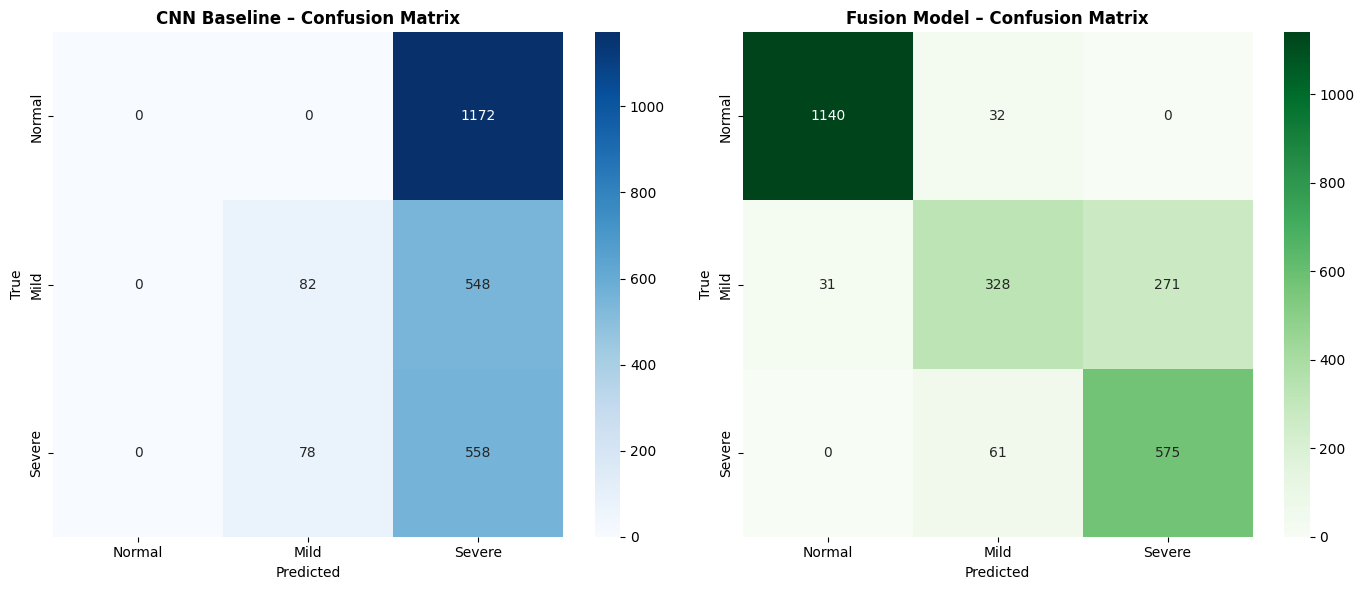

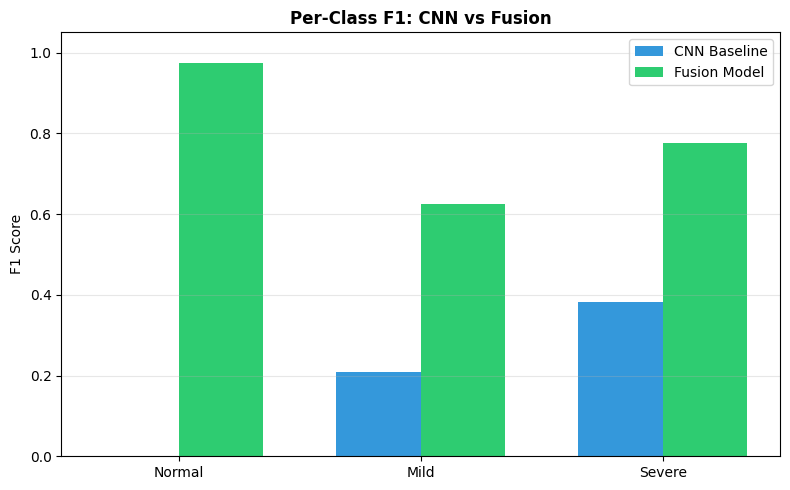

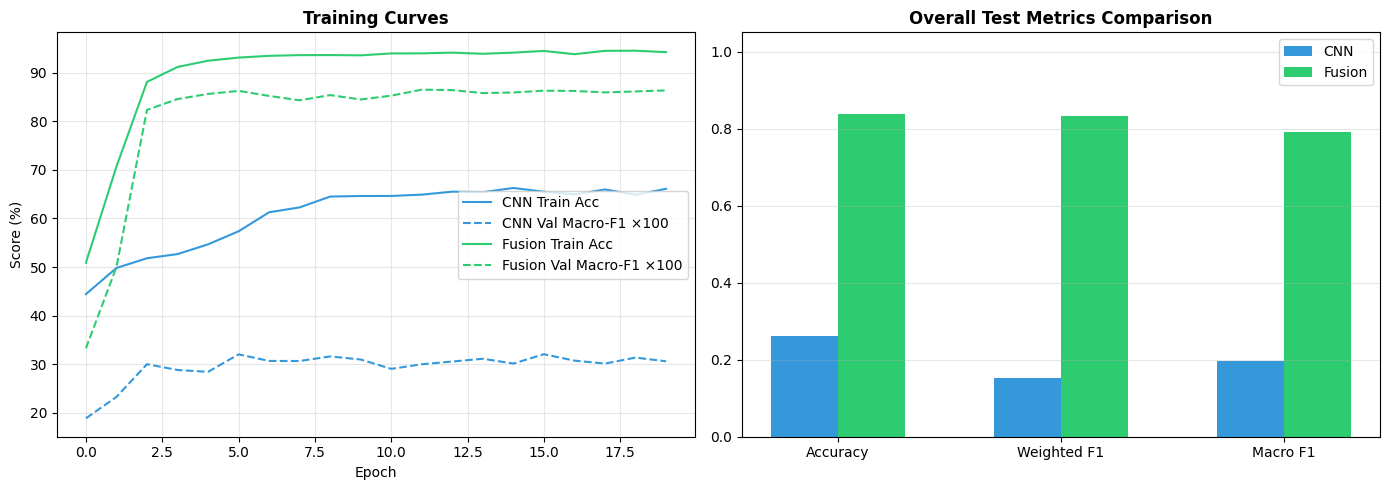

In [14]:
## ── PHASE M: EVALUATION ────────────────────────────────────

print("\n" + "=" * 60)
print("PHASE M – TEST SET EVALUATION")
print("=" * 60)

def eval_model_images(model, loader):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc="Eval CNN", leave=False):
            imgs = imgs.to(device)
            out  = model(imgs)
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(lbls.numpy())
    return np.array(labels), np.array(preds)


def eval_model_fusion(model, loader):
    model.eval()
    preds, labels, probs_all = [], [], []
    with torch.no_grad():
        for imgs, clinical, lbls in tqdm(loader, desc="Eval Fusion", leave=False):
            imgs     = imgs.to(device)
            clinical = clinical.to(device)
            out, _, _ = model(imgs, clinical)
            prob = F.softmax(out, dim=1)
            preds.extend(out.argmax(1).cpu().numpy())
            labels.extend(lbls.numpy())
            probs_all.extend(prob.cpu().numpy())
    return np.array(labels), np.array(preds), np.array(probs_all)


# ── Load best weights ──
cnn_model.load_state_dict(
    torch.load(RESULTS_DIR / "cnn_best.pth", map_location=device)
)
fusion_model.load_state_dict(
    torch.load(RESULTS_DIR / "fusion_best.pth", map_location=device)
)

cnn_labels,    cnn_preds              = eval_model_images(cnn_model, test_img_loader)
fusion_labels, fusion_preds, f_probs  = eval_model_fusion(fusion_model, test_loader)

# ── Metrics ──
def get_metrics(labels, preds):
    acc  = accuracy_score(labels, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )
    mac_f1 = f1_score(labels, preds, average="macro", zero_division=0)
    return dict(accuracy=acc, precision=prec, recall=rec,
                weighted_f1=f1, macro_f1=mac_f1)

cnn_metrics    = get_metrics(cnn_labels,    cnn_preds)
fusion_metrics = get_metrics(fusion_labels, fusion_preds)

print("\n──────────── CNN BASELINE ────────────")
print(f"  Accuracy    : {cnn_metrics['accuracy']:.4f}")
print(f"  Weighted F1 : {cnn_metrics['weighted_f1']:.4f}")
print(f"  Macro F1    : {cnn_metrics['macro_f1']:.4f}")
print("\n" + classification_report(
    cnn_labels, cnn_preds,
    target_names=list(INVERSE_LABEL_MAPPING.values()), digits=4
))

print("\n──────────── FUSION MODEL ────────────")
print(f"  Accuracy    : {fusion_metrics['accuracy']:.4f}")
print(f"  Weighted F1 : {fusion_metrics['weighted_f1']:.4f}")
print(f"  Macro F1    : {fusion_metrics['macro_f1']:.4f}")
print("\n" + classification_report(
    fusion_labels, fusion_preds,
    target_names=list(INVERSE_LABEL_MAPPING.values()), digits=4
))

# ── Confusion matrices ──
cnn_cm    = confusion_matrix(cnn_labels,    cnn_preds)
fusion_cm = confusion_matrix(fusion_labels, fusion_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(cnn_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=INVERSE_LABEL_MAPPING.values(),
            yticklabels=INVERSE_LABEL_MAPPING.values(), ax=axes[0])
axes[0].set_title("CNN Baseline – Confusion Matrix", fontweight="bold")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

sns.heatmap(fusion_cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=INVERSE_LABEL_MAPPING.values(),
            yticklabels=INVERSE_LABEL_MAPPING.values(), ax=axes[1])
axes[1].set_title("Fusion Model – Confusion Matrix", fontweight="bold")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "cnn_vs_fusion_confusion.png", dpi=150)
plt.show()

# ── Per-class F1 comparison ──
_, _, cnn_f1_per, _    = precision_recall_fscore_support(
    cnn_labels, cnn_preds, average=None, zero_division=0)
_, _, fusion_f1_per, _ = precision_recall_fscore_support(
    fusion_labels, fusion_preds, average=None, zero_division=0)

x = np.arange(NUM_CLASSES); w = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w/2, cnn_f1_per,    w, label="CNN Baseline", color="#3498db")
ax.bar(x + w/2, fusion_f1_per, w, label="Fusion Model", color="#2ecc71")
ax.set_xticks(x)
ax.set_xticklabels(list(INVERSE_LABEL_MAPPING.values()))
ax.set_ylabel("F1 Score"); ax.set_ylim(0, 1.05)
ax.set_title("Per-Class F1: CNN vs Fusion", fontweight="bold")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "f1_per_class_comparison.png", dpi=150)
plt.show()

# ── Training curves ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cnn_history["train_acc"], label="CNN Train Acc", color="#3498db")
axes[0].plot([v*100 for v in cnn_history["val_f1"]],
             label="CNN Val Macro-F1 ×100", linestyle="--", color="#3498db")
axes[0].plot(fusion_history["train_acc"], label="Fusion Train Acc", color="#2ecc71")
axes[0].plot([v*100 for v in fusion_history["val_f1"]],
             label="Fusion Val Macro-F1 ×100", linestyle="--", color="#2ecc71")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Score (%)")
axes[0].set_title("Training Curves", fontweight="bold")
axes[0].legend(); axes[0].grid(alpha=0.3)

metrics_list = ["accuracy", "weighted_f1", "macro_f1"]
cnn_vals    = [cnn_metrics[m]    for m in metrics_list]
fusion_vals = [fusion_metrics[m] for m in metrics_list]
xx = np.arange(len(metrics_list)); ww = 0.3
axes[1].bar(xx - ww/2, cnn_vals,    ww, label="CNN",    color="#3498db")
axes[1].bar(xx + ww/2, fusion_vals, ww, label="Fusion", color="#2ecc71")
axes[1].set_xticks(xx)
axes[1].set_xticklabels(["Accuracy", "Weighted F1", "Macro F1"])
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Overall Test Metrics Comparison", fontweight="bold")
axes[1].legend(); axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_and_comparison.png", dpi=150)
plt.show()

In [16]:
## ── PHASE N: SAVE SUMMARY ──────────────────────────────────

summary = {
    "cnn_baseline" : cnn_metrics,
    "fusion_model" : fusion_metrics,
    "improvement"  : {
        "accuracy_delta"    : round(fusion_metrics["accuracy"]    - cnn_metrics["accuracy"],    4),
        "weighted_f1_delta" : round(fusion_metrics["weighted_f1"] - cnn_metrics["weighted_f1"], 4),
        "macro_f1_delta"    : round(fusion_metrics["macro_f1"]    - cnn_metrics["macro_f1"],    4),
    }
}

with open(RESULTS_DIR / "experiment_summary.json", "w") as f:
    json.dump(summary, f, indent=4)

print("\n" + "=" * 60)
print("EXPERIMENT COMPLETE")
print("=" * 60)
print(json.dumps(summary, indent=2))
print(f"\n✓ All results saved to {RESULTS_DIR}")



EXPERIMENT COMPLETE
{
  "cnn_baseline": {
    "accuracy": 0.26251025430680885,
    "precision": 0.196334819052448,
    "recall": 0.26251025430680885,
    "weighted_f1": 0.15355179582103717,
    "macro_f1": 0.19685788670437201
  },
  "fusion_model": {
    "accuracy": 0.8379819524200164,
    "precision": 0.8466260805436526,
    "recall": 0.8379819524200164,
    "weighted_f1": 0.8315153086253337,
    "macro_f1": 0.7910857542554277
  },
  "improvement": {
    "accuracy_delta": 0.5755,
    "weighted_f1_delta": 0.678,
    "macro_f1_delta": 0.5942
  }
}

✓ All results saved to results
